In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
pd.set_option('display.max_colwidth', None)

In [4]:
complaints = pd.read_excel("Consumer_Complaints.xlsx")
complaints

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an existing mortgage,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money service",Refund anticipation check,Lost or stolen check,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,Yes
2,5818349,Web,2022-07-27,2022-07-27,CA,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
3,7233015,Referral,2023-07-10,2023-07-11,CA,Credit card or prepaid card,General-purpose prepaid card,Problem getting a card or closing an account,"Trouble getting, activating, or registering a card",NaN,In progress,NaN
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
62511,2501211,Web,2017-06-04,2017-06-04,TX,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62512,2472406,Referral,2017-05-01,2017-05-05,VA,Checking or savings account,Other banking product or service,Problem caused by your funds being low,Non-sufficient funds and associated fees,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62513,3704015,Web,2020-06-17,2020-06-17,TN,"Credit reporting, credit repair services, or other personal consumer reports",Credit repair services,Confusing or missing disclosures,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes
62514,2488973,Referral,2017-05-19,2017-05-19,GA,Mortgage,Other type of mortgage,Trouble during payment process,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes


## Handling Null Values

In [5]:
complaints.isnull().sum()

Complaint ID                        0
Submitted via                       0
Date submitted                      0
Date received                       0
State                               0
Product                             0
Sub-product                         7
Issue                               0
Sub-issue                       10858
Company public response          2175
Company response to consumer        0
Timely response?                 1494
dtype: int64

In [6]:
complaints["Sub-issue"].fillna("Not Specified",inplace= True)

complaints

In [7]:
complaints = complaints.dropna(subset=["Sub-product"])

In [8]:
complaints["Timely response?"].value_counts()

Timely response?
Yes    58612
No      2403
Name: count, dtype: int64

In [9]:
complaints[complaints["Timely response?"].isna()]["Company response to consumer"].value_counts()

Company response to consumer
In progress    1494
Name: count, dtype: int64

In [10]:
complaints["Timely response?"].fillna("Pending",inplace = True)

C:\Users\hp\AppData\Local\Temp\ipykernel_20412\3275707752.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complaints["Timely response?"].fillna("Pending",inplace = True)


In [11]:
complaints["Company public response"].fillna("No Public Response",inplace = True)

C:\Users\hp\AppData\Local\Temp\ipykernel_20412\1656281651.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complaints["Company public response"].fillna("No Public Response",inplace = True)


In [12]:
complaints.isnull().sum()

Complaint ID                    0
Submitted via                   0
Date submitted                  0
Date received                   0
State                           0
Product                         0
Sub-product                     0
Issue                           0
Sub-issue                       0
Company public response         0
Company response to consumer    0
Timely response?                0
dtype: int64

For Handling null values 
1. Sub-issues -- filled null values with "Not Specified".
2. Sub-products -- As there were only 7 null values therefore they can be droped.
3. Company public response -- Filled with "No Public Response".
4. Timely Response -- Na values are for rows where the "Company response to consumer" is "IN progess", therefore they can be replaced by "In Progess".

### Feature Engineering

In [13]:
complaints["Delay period"] = complaints["Date received"]-complaints["Date submitted"]

C:\Users\hp\AppData\Local\Temp\ipykernel_20412\2839061245.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complaints["Delay period"] = complaints["Date received"]-complaints["Date submitted"]


In [14]:
complaints["Delay period"] = complaints["Delay period"].dt.days

C:\Users\hp\AppData\Local\Temp\ipykernel_20412\2862466099.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complaints["Delay period"] = complaints["Delay period"].dt.days


In [15]:
complaints

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?,Delay period
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an existing mortgage,Not Specified,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes,3
1,3621464,Web,2020-04-24,2020-04-24,FL,"Money transfer, virtual currency, or money service",Refund anticipation check,Lost or stolen check,Not Specified,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,Yes,0
2,5818349,Web,2022-07-27,2022-07-27,CA,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes,0
3,7233015,Referral,2023-07-10,2023-07-11,CA,Credit card or prepaid card,General-purpose prepaid card,Problem getting a card or closing an account,"Trouble getting, activating, or registering a card",No Public Response,In progress,Pending,1
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit card or prepaid card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62511,2501211,Web,2017-06-04,2017-06-04,TX,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes,0
62512,2472406,Referral,2017-05-01,2017-05-05,VA,Checking or savings account,Other banking product or service,Problem caused by your funds being low,Non-sufficient funds and associated fees,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes,4
62513,3704015,Web,2020-06-17,2020-06-17,TN,"Credit reporting, credit repair services, or other personal consumer reports",Credit repair services,Confusing or missing disclosures,Not Specified,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes,0
62514,2488973,Referral,2017-05-19,2017-05-19,GA,Mortgage,Other type of mortgage,Trouble during payment process,Not Specified,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes,0


In [16]:
other = pd.read_csv("ConsumerComplaints_DataDictionary.csv")
other

,Field,Description
0,Complaint ID,The unique identification number for a complaint
1,Submitted via,How the complaint was submitted to the CFPB
2,Date submitted,The date the CFPB received the complaint
3,Date received,The date the CFPB sent the complaint to the company
4,State,The state of the mailing address provided by the consumer
5,Product,The type of product the consumer identified in the complaint
6,Sub-product,The type of sub-product the consumer identified in the complaint (not all Products have Sub-products)
7,Issue,The issue the consumer identified in the complaint (possible values are dependent on Product)
8,Sub-issue,"The sub-issue the consumer identified in the complaint (oossible values are dependent on Product and Issue, and not all Issues have corresponding Sub-issues)"
9,Company public response,"The company's optional, public-facing response to a consumer's complaint. Companies can choose to select a response from a pre-set list of options that will be posted on the public database. For example, ""Company believes complaint is the result of an isolated error."""


## Data Cleaning

####  Now We have to map all the values of Product, sub-products,issue and company public response

1. Product

In [17]:
complaints["Product"].unique()

array(['Mortgage', 'Money transfer, virtual currency, or money service',
       'Credit reporting, credit repair services, or other personal consumer reports',
       'Credit card or prepaid card', 'Checking or savings account',
       'Vehicle loan or lease', 'Debt collection',
       'Payday loan, title loan, or personal loan', 'Student loan'],
      dtype=object)

In [18]:
product_mapping = {
    "Mortgage": "Mortgage",
    
    "Money transfer, virtual currency, or money service": 
        "Money Transfer / Crypto",
    
    "Credit reporting, credit repair services, or other personal consumer reports": 
        "Credit Reporting",
    
    "Credit card or prepaid card": 
        "Credit Card",
    
    "Checking or savings account": 
        "Deposit Account",
    
    "Vehicle loan or lease": 
        "Auto Loan/Lease",
    
    "Debt collection": 
        "Debt Collection",
    
    "Payday loan, title loan, or personal loan": 
        "Payday / Personal Loan",
    
    "Student loan": 
        "Student Loan"
}
complaints["Product"] = complaints["Product"].map(product_mapping)

C:\Users\hp\AppData\Local\Temp\ipykernel_20412\1051252990.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complaints["Product"] = complaints["Product"].map(product_mapping)


In [19]:
complaints

,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?,Delay period
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an existing mortgage,Not Specified,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes,3
1,3621464,Web,2020-04-24,2020-04-24,FL,Money Transfer / Crypto,Refund anticipation check,Lost or stolen check,Not Specified,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with monetary relief,Yes,0
2,5818349,Web,2022-07-27,2022-07-27,CA,Credit Reporting,Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes,0
3,7233015,Referral,2023-07-10,2023-07-11,CA,Credit Card,General-purpose prepaid card,Problem getting a card or closing an account,"Trouble getting, activating, or registering a card",No Public Response,In progress,Pending,1
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit Card,General-purpose credit card or charge card,Closing your account,Company closed your account,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62511,2501211,Web,2017-06-04,2017-06-04,TX,Deposit Account,Checking account,Managing an account,Problem using a debit or ATM card,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes,0
62512,2472406,Referral,2017-05-01,2017-05-05,VA,Deposit Account,Other banking product or service,Problem caused by your funds being low,Non-sufficient funds and associated fees,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes,4
62513,3704015,Web,2020-06-17,2020-06-17,TN,Credit Reporting,Credit repair services,Confusing or missing disclosures,Not Specified,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes,0
62514,2488973,Referral,2017-05-19,2017-05-19,GA,Mortgage,Other type of mortgage,Trouble during payment process,Not Specified,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Closed with explanation,Yes,0


2. Sub-products

In [20]:
complaints["Sub-product"].unique()

array(['Conventional home mortgage', 'Refund anticipation check',
       'Credit reporting', 'General-purpose prepaid card',
       'General-purpose credit card or charge card', 'Checking account',
       'Other banking product or service', 'International money transfer',
       'Loan', 'Credit card debt', 'Personal line of credit',
       'Mortgage debt', 'Mobile or digital wallet', 'Savings account',
       'Home equity loan or line of credit (HELOC)',
       'Other type of mortgage', 'Government benefit card',
       'Domestic (US) money transfer', 'FHA mortgage', 'I do not know',
       'Credit repair services', 'Store credit card', 'Other debt',
       'Virtual currency', 'Money order', 'CD (Certificate of Deposit)',
       'Foreign currency exchange', "Traveler's check or cashier's check",
       'Reverse mortgage', 'Federal student loan debt',
       'Other personal consumer report', 'VA mortgage',
       'Installment loan', 'Private student loan debt',
       'Check cashing ser

In [21]:
subproduct_mapping = {

    # Mortgage
    "Conventional home mortgage": "Conventional Mortgage",
    "FHA mortgage": "FHA Mortgage",
    "VA mortgage": "VA Mortgage",
    "Reverse mortgage": "Reverse Mortgage",
    "Other type of mortgage": "Other Mortgage",
    "Home equity loan or line of credit (HELOC)": "HELOC",
    "Mortgage debt": "Mortgage Debt",

    # Student Loans
    "Federal student loan": "Federal Student Loan",
    "Federal student loan debt": "Federal Student Loan Debt",
    "Federal student loan servicing": "Federal Student Loan Servicing",
    "Private student loan": "Private Student Loan",
    "Private student loan debt": "Private Student Loan Debt",

    # Credit Cards
    "General-purpose credit card or charge card": "General Credit Card",
    "Store credit card": "Store Credit Card",
    "Credit card debt": "Credit Card Debt",
    "General-purpose prepaid card": "Prepaid Card",
    "Gift card": "Gift Card",
    "Payroll card": "Payroll Card",
    "Government benefit card": "Government Benefit Card",

    # Bank Accounts
    "Checking account": "Checking Account",
    "Savings account": "Savings Account",
    "CD (Certificate of Deposit)": "Certificate of Deposit",
    "Other banking product or service": "Other Banking Product",

    # Money Transfer / Currency
    "International money transfer": "International Transfer",
    "Domestic (US) money transfer": "Domestic Transfer",
    "Mobile or digital wallet": "Digital Wallet",
    "Virtual currency": "Cryptocurrency",
    "Money order": "Money Order",
    "Foreign currency exchange": "Currency Exchange",
    "Traveler's check or cashier's check": "Cashier/Traveler Check",
    "Check cashing service": "Check Cashing Service",

    # Personal Loans
    "Loan": "Personal Loan",
    "Installment loan": "Installment Loan",
    "Personal line of credit": "Personal Line of Credit",

    # Payday / Title Loans
    "Payday loan": "Payday Loan",
    "Payday loan debt": "Payday Loan Debt",
    "Title loan": "Title Loan",

    # Auto
    "Lease": "Auto Lease",
    "Auto debt": "Auto Debt",

    # Debt Collection
    "Debt settlement": "Debt Settlement",
    "Other debt": "Other Debt",
    "Medical debt": "Medical Debt",

    # Credit Reporting
    "Credit reporting": "Credit Reporting",
    "Credit repair services": "Credit Repair",
    "Other personal consumer report": "Other Credit Report",

    # Misc
    "Refund anticipation check": "Refund Check",
    "I do not know": "Unknown"
}

In [22]:
complaints["Sub-product"] = complaints["Sub-product"].map(subproduct_mapping)


C:\Users\hp\AppData\Local\Temp\ipykernel_20412\2704769468.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complaints["Sub-product"] = complaints["Sub-product"].map(subproduct_mapping)


3. Issues

In [23]:
issue_mapping = {
    "Applying for a mortgage or refinancing an existing mortgage": "Mortgage Application/Refinance",
    "Lost or stolen check": "Lost/Stolen Check",
    "Incorrect information on your report": "Incorrect Credit Info",
    "Problem getting a card or closing an account": "Card/Application/Closure Issue",
    "Closing your account": "Account Closure",
    "Getting a credit card": "Credit Card Application",
    "Closing an account": "Account Closure",
    "Fees or interest": "Fees/Interest",
    "Opening an account": "Account Opening",
    "Managing an account": "Account Management",
    "Fraud or scam": "Fraud/Scam",
    "Advertising and marketing, including promotional offers": "Advertising/Marketing",
    "Getting a loan or lease": "Loan/Lease Application",
    "Took or threatened to take negative or legal action": "Legal Action / Threats",
    "Problem with a credit reporting company's investigation into an existing problem": "Credit Report Investigation Issue",
    "Attempts to collect debt not owed": "Debt Collection - Not Owed",
    "Problem with a lender or other company charging your account": "Incorrect Charge",
    "Trouble during payment process": "Payment Processing Issue",
    "False statements or representation": "False Statements",
    "Problem with a purchase shown on your statement": "Purchase Dispute",
    "Struggling to pay mortgage": "Mortgage Repayment Difficulty",
    "Problem with a purchase or transfer": "Purchase/Transfer Issue",
    "Other transaction problem": "Other Transaction Problem",
    "Struggling to pay your loan": "Loan Repayment Difficulty",
    "Other features, terms, or problems": "Product Features/Terms",
    "Written notification about debt": "Debt Notice",
    "Trouble using the card": "Card Usage Problem",
    "Confusing or missing disclosures": "Disclosure Issues",
    "Problem when making payments": "Payment Issue",
    "Improper use of your report": "Improper Credit Report Use",
    "Problem caused by your funds being low": "Insufficient Funds",
    "Other service problem": "Other Service Problem",
    "Money was not available when promised": "Funds Not Available",
    "Wrong amount charged or received": "Incorrect Amount Charged",
    "Closing on a mortgage": "Mortgage Closing",
    "Trouble using your card": "Card Usage Problem",
    "Struggling to pay your bill": "Bill Repayment Difficulty",
    "Managing the loan or lease": "Loan/Lease Management",
    "Unexpected or other fees": "Unexpected Fees",
    "Problem with customer service": "Customer Service Issue",
    "Problem with fraud alerts or security freezes": "Fraud Alerts / Security Freeze",
    "Communication tactics": "Communication Tactics",
    "Problems at the end of the loan or lease": "End-of-Loan/Lease Issues",
    "Unauthorized transactions or other transaction problem": "Unauthorized Transaction",
    "Problem with a company's investigation into an existing issue": "Company Investigation Issue",
    "Credit monitoring or identity theft protection services": "Identity Protection Services",
    "Getting a line of credit": "Line of Credit Application",
    "Problem with cash advance": "Cash Advance Problem",
    "Unable to get your credit report or credit score": "Unable to Access Credit Report",
    "Identity theft protection or other monitoring services": "Identity Protection Services",
    "Charged fees or interest you didn't expect": "Unexpected Fees/Interest",
    "Problem with additional add-on products or services": "Add-on Product Issues",
    "Problem with overdraft": "Overdraft Issue",
    "Advertising": "Advertising",
    "Loan payment wasn't credited to your account": "Payment Not Credited",
    "Incorrect exchange rate": "Incorrect Exchange Rate",
    "Problem with the payoff process at the end of the loan": "Loan Payoff Process Issue",
    "Managing, opening, or closing your mobile wallet account": "Mobile Wallet Account Issue",
    "Threatened to contact someone or share information improperly": "Threats / Improper Contact",
    "Was approved for a loan, but didn't receive money": "Approved but No Funds",
    "Confusing or misleading advertising or marketing": "Misleading Advertising",
    "Can't contact lender or servicer": "Unable to Contact Lender/Servicer",
    "Credit limit changed": "Credit Limit Change",
    "Lost or stolen money order": "Lost/Stolen Money Order",
    "Getting the loan": "Loan Disbursement",
    "Dealing with your lender or servicer": "Loan Servicing / Lender Interaction",
    "Overdraft, savings, or rewards features": "Account Features",
    "Struggling to repay your loan": "Loan Repayment Difficulty",
    "Problem adding money": "Deposit / Add Funds Issue",
    "Was approved for a loan, but didn't receive the money": "Approved but No Funds",
    "Excessive fees": "Excessive Fees",
    "Getting a loan": "Loan Application",
    "Vehicle was damaged or destroyed the vehicle": "Vehicle Damage",
    "Problem with an overdraft": "Overdraft Issue",
    "Vehicle was repossessed or sold the vehicle": "Vehicle Repossession",
    "Can't stop withdrawals from your bank account": "Unable to Stop Withdrawals"
}


In [24]:
complaints["Issue"] = complaints["Issue"].map(issue_mapping)

C:\Users\hp\AppData\Local\Temp\ipykernel_20412\1079359545.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complaints["Issue"] = complaints["Issue"].map(issue_mapping)


4. Company public Response

In [25]:
complaints["Company public response"].unique()

array(['Company has responded to the consumer and the CFPB and chooses not to provide a public response',
       'No Public Response',
       "Company believes the complaint provided an opportunity to answer consumer's questions",
       'Company disputes the facts presented in the complaint',
       'Company believes the complaint is the result of a misunderstanding',
       'Company believes it acted appropriately as authorized by contract or law',
       'Company believes complaint caused principally by actions of third party outside the control or direction of the company'],
      dtype=object)

In [26]:
company_response_mapping = {

    # No Public Response
    "No Public Response": "No Public Response",
    "Company has responded to the consumer and the CFPB and chooses not to provide a public response":
        "No Public Response",

    # Informational / Clarification
    "Company believes the complaint provided an opportunity to answer consumer's questions":
        "Provided Explanation",
    "Company believes the complaint is the result of a misunderstanding":
        "Customer Misunderstanding",

    # Dispute
    "Company disputes the facts presented in the complaint":
        "Disputes Complaint",

    # Justification / Compliance
    "Company believes it acted appropriately as authorized by contract or law":
        "Acted Within Contract/Law",

    # Third Party Blame
    "Company believes complaint caused principally by actions of third party outside the control or direction of the company":
        "Blames Third Party"
}


In [27]:
complaints["Company public response"] = complaints["Company public response"].map(company_response_mapping)
complaints

C:\Users\hp\AppData\Local\Temp\ipykernel_20412\3595905034.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complaints["Company public response"] = complaints["Company public response"].map(company_response_mapping)


,Complaint ID,Submitted via,Date submitted,Date received,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?,Delay period
0,4848023,Referral,2021-10-24,2021-10-27,NY,Mortgage,Conventional Mortgage,Mortgage Application/Refinance,Not Specified,No Public Response,Closed with explanation,Yes,3
1,3621464,Web,2020-04-24,2020-04-24,FL,Money Transfer / Crypto,Refund Check,Lost/Stolen Check,Not Specified,No Public Response,Closed with monetary relief,Yes,0
2,5818349,Web,2022-07-27,2022-07-27,CA,Credit Reporting,Credit Reporting,Incorrect Credit Info,Account information incorrect,No Public Response,Closed with explanation,Yes,0
3,7233015,Referral,2023-07-10,2023-07-11,CA,Credit Card,Prepaid Card,Card/Application/Closure Issue,"Trouble getting, activating, or registering a card",No Public Response,In progress,Pending,1
4,5820224,Referral,2022-07-27,2022-07-28,VA,Credit Card,General Credit Card,Account Closure,Company closed your account,No Public Response,Closed with explanation,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62511,2501211,Web,2017-06-04,2017-06-04,TX,Deposit Account,Checking Account,Account Management,Problem using a debit or ATM card,No Public Response,Closed with explanation,Yes,0
62512,2472406,Referral,2017-05-01,2017-05-05,VA,Deposit Account,Other Banking Product,Insufficient Funds,Non-sufficient funds and associated fees,No Public Response,Closed with explanation,Yes,4
62513,3704015,Web,2020-06-17,2020-06-17,TN,Credit Reporting,Credit Repair,Disclosure Issues,Not Specified,No Public Response,Closed with explanation,Yes,0
62514,2488973,Referral,2017-05-19,2017-05-19,GA,Mortgage,Other Mortgage,Payment Processing Issue,Not Specified,No Public Response,Closed with explanation,Yes,0


In [28]:
complaints["Company response to consumer"]

0            Closed with explanation
1        Closed with monetary relief
2            Closed with explanation
3                        In progress
4            Closed with explanation
                    ...             
62511        Closed with explanation
62512        Closed with explanation
62513        Closed with explanation
62514        Closed with explanation
62515        Closed with explanation
Name: Company response to consumer, Length: 62509, dtype: object

5. Mapping Sub-issues

In [31]:
subissues_map = sub_issue_mapping = {

    # ---------------- Transaction Issues ----------------
    "Deposits and withdrawals": "Transaction Issues",
    "Deposits or withdrawals": "Transaction Issues",
    "Problem using a debit or ATM card": "Transaction Issues",
    "Problem using the card to withdraw money from an ATM": "Transaction Issues",
    "Problem making or receiving payments": "Transaction Issues",
    "Problem during payment process": "Transaction Issues",
    "Transaction was not authorized": "Transaction Issues",
    "Money was taken from your account on the wrong day or for the wrong amount": "Transaction Issues",
    "Cashing a check": "Transaction Issues",
    "Problem with direct deposit": "Transaction Issues",
    "Bounced checks or returned payments": "Transaction Issues",
    "Problem adding money": "Transaction Issues",

    # ---------------- Fraud / Identity Theft ----------------
    "Account opened as a result of fraud": "Fraud / Identity Theft",
    "Card opened as result of identity theft or fraud": "Fraud / Identity Theft",
    "Debt was result of identity theft": "Fraud / Identity Theft",
    "Card opened without my consent or knowledge": "Fraud / Identity Theft",
    "Impersonated attorney, law enforcement, or government official": "Fraud / Identity Theft",

    # ---------------- Fees & Charges ----------------
    "Problem with fees": "Fees & Charges",
    "Fee problem": "Fees & Charges",
    "Problem with fees charged": "Fees & Charges",
    "Overdrafts and overdraft fees": "Fees & Charges",
    "Overdraft charges": "Fees & Charges",
    "Late or other fees": "Fees & Charges",
    "Charged too much interest": "Fees & Charges",
    "Unexpected increase in interest rate": "Fees & Charges",

    # ---------------- Account Management ----------------
    "Account information incorrect": "Account Management",
    "Account status incorrect": "Account Management",
    "Problem accessing account": "Account Management",
    "Company closed your account": "Account Management",
    "Can't close your account": "Account Management",
    "Funds not received from closed account": "Account Management",
    "Unable to open an account": "Account Management",

    # ---------------- Customer Service ----------------
    "Problem with customer service": "Customer Service",
    "Trouble getting information about the card": "Customer Service",
    "Difficulty submitting a dispute or getting information about a dispute over the phone": "Customer Service",

    # ---------------- Dispute Resolution ----------------
    "Problem with personal statement of dispute": "Dispute Resolution",
    "Credit card company isn't resolving a dispute about a purchase on your statement": "Dispute Resolution",
    "Card company isn't resolving a dispute about a purchase or transfer": "Dispute Resolution",
    "Billing dispute for services": "Dispute Resolution",

    # ---------------- Debt Collection Issues ----------------
    "Debt is not yours": "Debt Collection Issues",
    "Threatened to sue you for very old debt": "Debt Collection Issues",
    "Frequent or repeated calls": "Debt Collection Issues",
    "Talked to a third-party about your debt": "Debt Collection Issues",
    "Contacted you after you asked them to stop": "Debt Collection Issues",
    "Called before 8am or after 9pm": "Debt Collection Issues",

    # ---------------- Credit Reporting Issues ----------------
    "Information belongs to someone else": "Credit Reporting Issues",
    "Personal information incorrect": "Credit Reporting Issues",
    "Information is incorrect": "Credit Reporting Issues",
    "Old information reappears or never goes away": "Credit Reporting Issues",
    "Public record information inaccurate": "Credit Reporting Issues",

    # ---------------- Loan Servicing Issues ----------------
    "Denied loan": "Loan Servicing Issues",
    "Problem with paying off the loan": "Loan Servicing Issues",
    "Need information about your loan balance or loan terms": "Loan Servicing Issues",
    "Trouble with how payments are being handled": "Loan Servicing Issues",
    "Problem related to refinancing": "Loan Servicing Issues",

    # ---------------- Marketing / Disclosure Issues ----------------
    "Confusing or misleading advertising about the credit card": "Marketing / Disclosure Issues",
    "Confusing or misleading advertising or marketing": "Marketing / Disclosure Issues",
    "Didn't receive advertised or promotional terms": "Marketing / Disclosure Issues",
    "Changes in terms mid-deal or after closing": "Marketing / Disclosure Issues",

    # ---------------- Legal / Compliance ----------------
    "Sued you without properly notifying you of lawsuit": "Legal / Compliance",
    "Seized or attempted to seize your property": "Legal / Compliance",
    "Notification didn't disclose it was an attempt to collect a debt": "Legal / Compliance",

    # ---------------- Default ----------------
    "Not Specified": "Other / Not Specified",
    "Other problem": "Other / Not Specified"
}

In [32]:
complaints["Sub-issue"] = complaints["Sub-issue"].map(subissues_map)

C:\Users\hp\AppData\Local\Temp\ipykernel_20412\426686401.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complaints["Sub-issue"] = complaints["Sub-issue"].map(subissues_map)


In [33]:
## Re-ordering Delay period column
col = complaints.pop("Delay period")
complaints.insert(4,"Delay period",col)

## Answering Research Questions

### Do consumer complaints show any seasonal patterns?

In [34]:
complaints.sort_values(by = "Date submitted",axis = 0)

,Complaint ID,Submitted via,Date submitted,Date received,Delay period,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?
27697,2471544,Web,2017-05-01,2017-05-04,3,FL,Money Transfer / Crypto,Currency Exchange,Incorrect Exchange Rate,Other / Not Specified,No Public Response,Closed with monetary relief,Yes
51422,2471723,Web,2017-05-01,2017-05-03,2,CA,Mortgage,Conventional Mortgage,Mortgage Repayment Difficulty,Other / Not Specified,No Public Response,Closed with explanation,Yes
60602,2533147,Referral,2017-05-01,2017-07-18,78,SC,Credit Card,General Credit Card,Purchase Dispute,NaN,No Public Response,Closed with explanation,Yes
60874,2540884,Referral,2017-05-01,2017-07-18,78,SC,Credit Card,General Credit Card,Credit Card Application,NaN,No Public Response,Closed with explanation,Yes
46986,2472131,Web,2017-05-01,2017-05-04,3,CA,Credit Card,General Credit Card,Fees/Interest,Fees & Charges,No Public Response,Closed with monetary relief,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30295,7443444,Web,2023-08-23,2023-08-23,0,NJ,Deposit Account,Checking Account,Account Closure,Account Management,No Public Response,Closed with explanation,Yes
10926,7445929,Phone,2023-08-23,2023-08-23,0,CA,Credit Card,General Credit Card,Purchase Dispute,NaN,No Public Response,In progress,Pending
11933,7453282,Web,2023-08-24,2023-08-24,0,TX,Money Transfer / Crypto,Domestic Transfer,Funds Not Available,Other / Not Specified,No Public Response,In progress,Pending
3422,7456107,Web,2023-08-25,2023-08-25,0,IL,Credit Card,General Credit Card,Credit Card Application,Fraud / Identity Theft,No Public Response,In progress,Pending


In [35]:
complaints["Month"] = complaints["Date submitted"].dt.to_period("M")

C:\Users\hp\AppData\Local\Temp\ipykernel_20412\4256240928.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complaints["Month"] = complaints["Date submitted"].dt.to_period("M")


In [36]:
complaints.insert(5,"Month",complaints.pop("Month"))

In [37]:
comp_by_mnth = complaints.groupby("Month").size().reset_index(name = "Complaint_count")

In [38]:
comp_by_mnth["Month"] = comp_by_mnth["Month"].astype(str)

In [39]:
comp_by_mnth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Month            76 non-null     object
 1   Complaint_count  76 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ KB


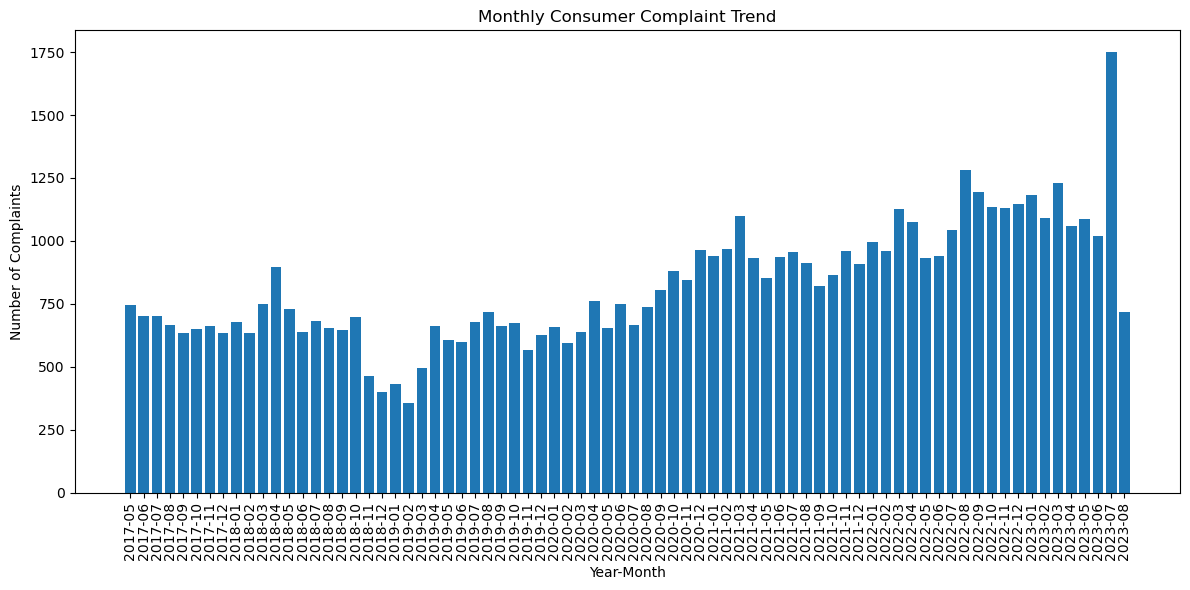

In [40]:
plt.figure(figsize=(12,6))
plt.bar(comp_by_mnth["Month"], comp_by_mnth["Complaint_count"],)
plt.xticks(rotation=90)
plt.title("Monthly Consumer Complaint Trend")
plt.xlabel("Year-Month")
plt.ylabel("Number of Complaints")
plt.tight_layout()
plt.show()

In [41]:
complaints["Year"] = complaints["Date submitted"].dt.year

C:\Users\hp\AppData\Local\Temp\ipykernel_20412\3421777167.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complaints["Year"] = complaints["Date submitted"].dt.year


In [42]:
complaints

,Complaint ID,Submitted via,Date submitted,Date received,Delay period,Month,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?,Year
0,4848023,Referral,2021-10-24,2021-10-27,3,2021-10,NY,Mortgage,Conventional Mortgage,Mortgage Application/Refinance,Other / Not Specified,No Public Response,Closed with explanation,Yes,2021
1,3621464,Web,2020-04-24,2020-04-24,0,2020-04,FL,Money Transfer / Crypto,Refund Check,Lost/Stolen Check,Other / Not Specified,No Public Response,Closed with monetary relief,Yes,2020
2,5818349,Web,2022-07-27,2022-07-27,0,2022-07,CA,Credit Reporting,Credit Reporting,Incorrect Credit Info,Account Management,No Public Response,Closed with explanation,Yes,2022
3,7233015,Referral,2023-07-10,2023-07-11,1,2023-07,CA,Credit Card,Prepaid Card,Card/Application/Closure Issue,NaN,No Public Response,In progress,Pending,2023
4,5820224,Referral,2022-07-27,2022-07-28,1,2022-07,VA,Credit Card,General Credit Card,Account Closure,Account Management,No Public Response,Closed with explanation,Yes,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62511,2501211,Web,2017-06-04,2017-06-04,0,2017-06,TX,Deposit Account,Checking Account,Account Management,Transaction Issues,No Public Response,Closed with explanation,Yes,2017
62512,2472406,Referral,2017-05-01,2017-05-05,4,2017-05,VA,Deposit Account,Other Banking Product,Insufficient Funds,NaN,No Public Response,Closed with explanation,Yes,2017
62513,3704015,Web,2020-06-17,2020-06-17,0,2020-06,TN,Credit Reporting,Credit Repair,Disclosure Issues,Other / Not Specified,No Public Response,Closed with explanation,Yes,2020
62514,2488973,Referral,2017-05-19,2017-05-19,0,2017-05,GA,Mortgage,Other Mortgage,Payment Processing Issue,Other / Not Specified,No Public Response,Closed with explanation,Yes,2017


In [43]:
with_year = complaints.groupby("Year").size().reset_index(name = "Complaint_count")

Text(0.5, 1.0, 'No. of complaints of products')

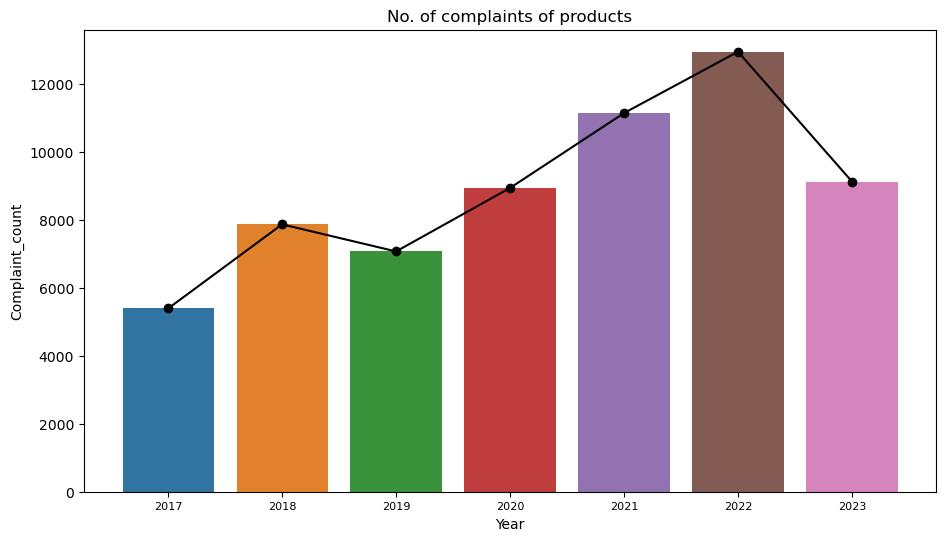

In [44]:
plt.figure(figsize=(11,6))
sns.barplot(x = with_year["Year"],y = with_year["Complaint_count"])
plt.plot(
    range(len(with_year)),
    with_year["Complaint_count"],
    marker="o",
    color="black"
)
plt.xticks(fontsize =8);
plt.title("No. of complaints of products")

There is an increasing trend in number of complaints year by year


There is a senior concern regarding this. Customer support team has to take this in account.

### Which products present the most complaints? What are its most common issues?

In [45]:
product_complaints = complaints.groupby("Product").size().reset_index(name = "No. of Complaints")

Text(0.5, 1.0, 'No. of complaints of products')

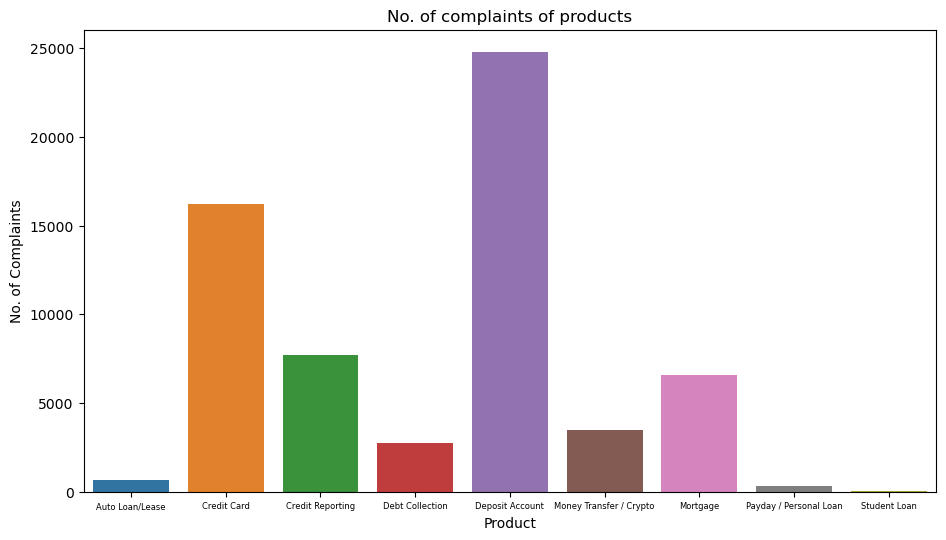

In [46]:
plt.figure(figsize=(11,6))
sns.barplot(x = product_complaints["Product"],y = product_complaints["No. of Complaints"])
plt.xticks(fontsize =6);
plt.title("No. of complaints of products")

1. Most Complaints are coming while checking or saving account

In [47]:
only_deposit_account = complaints[complaints["Product"] == "Deposit Account"]

In [48]:
only_deposit_account

,Complaint ID,Submitted via,Date submitted,Date received,Delay period,Month,State,Product,Sub-product,Issue,Sub-issue,Company public response,Company response to consumer,Timely response?,Year
6,4348292,Web,2021-05-04,2021-05-04,0,2021-05,TX,Deposit Account,Checking Account,Account Closure,Account Management,No Public Response,Closed with monetary relief,Yes,2021
9,6203657,Web,2022-11-14,2022-11-14,0,2022-11,VA,Deposit Account,Other Banking Product,Account Closure,Account Management,No Public Response,Closed with explanation,Yes,2022
11,5336959,Web,2022-03-18,2022-03-18,0,2022-03,KS,Deposit Account,Checking Account,Account Opening,Fraud / Identity Theft,No Public Response,Closed with explanation,Yes,2022
12,5618881,Web,2022-05-28,2022-05-28,0,2022-05,GA,Deposit Account,Checking Account,Account Management,Transaction Issues,No Public Response,Closed with explanation,Yes,2022
14,5618923,Web,2022-05-28,2022-05-28,0,2022-05,CA,Deposit Account,Checking Account,Account Management,Transaction Issues,No Public Response,Closed with explanation,Yes,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62506,5817092,Phone,2022-07-27,2022-07-27,0,2022-07,IL,Deposit Account,Checking Account,Account Management,Transaction Issues,No Public Response,Closed with explanation,Yes,2022
62507,6475744,Web,2023-01-23,2023-01-23,0,2023-01,NY,Deposit Account,Other Banking Product,Account Management,Account Management,No Public Response,Closed with explanation,Yes,2023
62510,5204472,Postal mail,2022-02-09,2022-02-09,0,2022-02,MA,Deposit Account,Checking Account,Account Management,Account Management,No Public Response,Closed with monetary relief,Yes,2022
62511,2501211,Web,2017-06-04,2017-06-04,0,2017-06,TX,Deposit Account,Checking Account,Account Management,Transaction Issues,No Public Response,Closed with explanation,Yes,2017


In [49]:
only_deposit_account["Sub-product"].value_counts()[:10].index

Index(['Checking Account', 'Other Banking Product', 'Savings Account',
       'Certificate of Deposit'],
      dtype='object', name='Sub-product')

In [50]:
labels = only_deposit_account["Sub-product"].value_counts()[:10].index

In [51]:
pallete_color = sns.color_palette('pastel')

In [52]:
only_deposit_account["Sub-product"].value_counts()[:5].sort_values(ascending=False)

Sub-product
Checking Account          20768
Other Banking Product      2568
Savings Account            1239
Certificate of Deposit      232
Name: count, dtype: int64

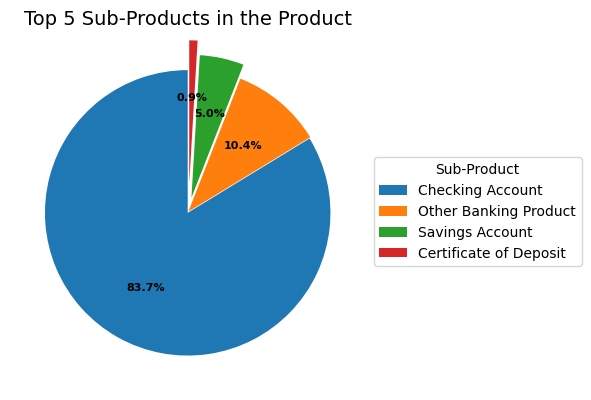

In [53]:
plt.figure(figsize=(6,6))

wedges, texts, autotexts = plt.pie(
    only_deposit_account["Sub-product"].value_counts()[:5].sort_values(ascending=False),
    autopct='%1.1f%%',
    startangle=90,explode = [0.01,0,0.1,0.2]
)
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_fontweight('bold')
    autotext.set_color('black')
plt.legend(
    wedges,
    labels,
    title="Sub-Product",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Top 5 Sub-Products in the Product", fontsize=14)
plt.tight_layout()
plt.show()

Complaints are overwhelmingly concentrated in the Checking Account product, indicating this is the primary risk exposure area for the bank.
1. Either checking accounts have very high usage volume

2. Or operational inefficiencies are concentrated in this product

3. Or digital/channel issues affect checking accounts most

In [54]:
labels2 = only_deposit_account["Issue"].value_counts()[:10].index

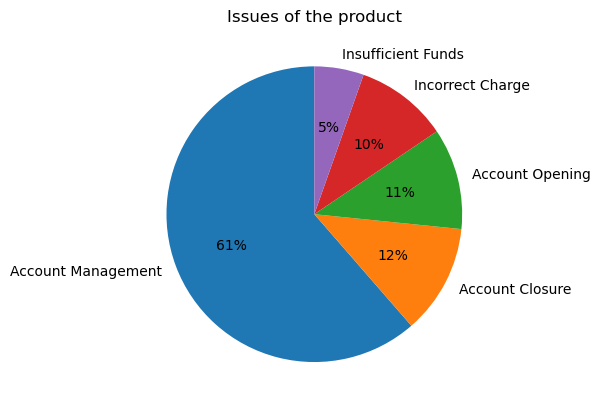

In [55]:
plt.pie(only_deposit_account["Issue"].value_counts()[:5],autopct='%.0f%%', startangle=90,labels = labels2[:5])
plt.title('Issues of the product')
plt.show()
plt.show()


The majority of complaints are operational (account management related), not fraud or credit-related.
Possible Causes:
System errors

1. Poor UX in digital banking

2. Delays in updates

3. Service workflow breakdowns

4. Customer confusion in managing accounts

In [72]:
labels3 = only_deposit_account["Sub-issue"].value_counts().index

In [ ]:
plt.figure(figsize=(5,5))
plt.pie(only_deposit_account["Sub-issue"].value_counts()[:5],autopct='%.0f%%', startangle=90,labels = labels3[:5],
        explode =(0.01,0.1,0.1,0.1,0.1), labeldistance=1.5,pctdistance=0.5)
plt.title('Top 5 Sub - Issues in the product')
plt.show()
plt.show()


### The main operational breakdown is happening at the transaction layer.
This is serious because:

1. Deposits & withdrawals are core banking functions

2. Card failures affect customer trust immediately

3. Unauthorized transactions increase regulatory risk

The complaint spike appears to be driven primarily by transaction processing and operational workflow inefficiencies within checking accounts.

### Possible Causes for all the above Issues can be listed as follows:
1. Backend system latency

2. ATM/network reconciliation problems

3. Batch processing delays

4. Digital banking sync errors

5. Fraud monitoring system friction

Complaint concentration suggests systemic friction in transaction processing and account lifecycle management within checking accounts, potentially driven by operational inefficiencies or digital channel limitations.

### Suggesetd Solutions:

1. Transaction processing audit

2. ATM & debit card reconciliation system review

3. Fraud monitoring workflow optimization

4. Account lifecycle automation improvements

<h1>Part - 2</h1>

### How are complaints typically resolved?

In [58]:
only_deposit_account["Company public response"].value_counts().index

Index(['No Public Response', 'Provided Explanation',
       'Acted Within Contract/Law', 'Customer Misunderstanding',
       'Blames Third Party'],
      dtype='object', name='Company public response')

<Axes: xlabel='Company response to consumer'>

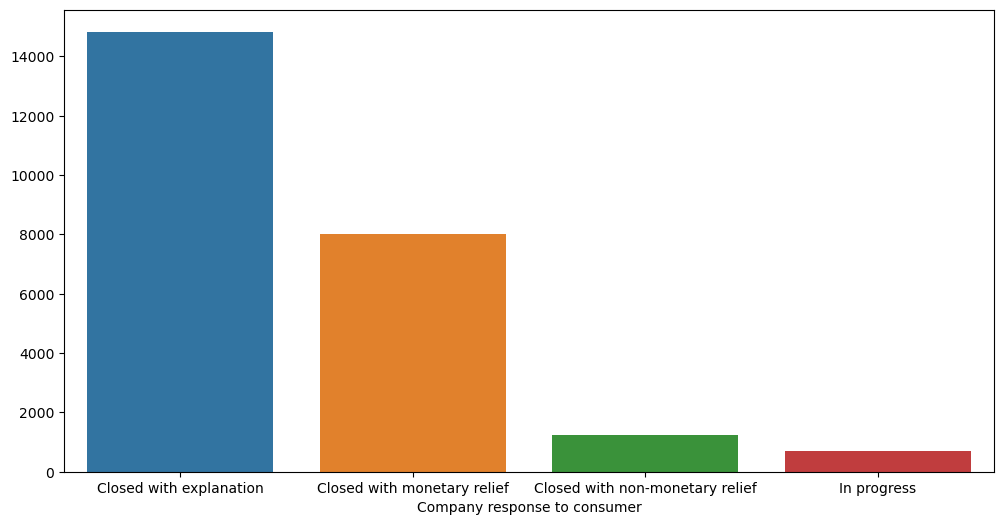

In [59]:
plt.figure(figsize = (12,6))
sns.barplot(x =  only_deposit_account["Company response to consumer"].value_counts().index,
            y =only_deposit_account["Company response to consumer"].value_counts().values )

Most of the complaints are handled by Explaination. However, a significant amount of the complaints are settled with monetary relief.
These Monetery relief are financial loss to the organization and has to be reduced as low as possible.

### Which are the complaints that are settled with monetary relief?

In [60]:
monetary_relief = complaints[complaints["Company response to consumer"] == "Closed with monetary relief"]

In [61]:
relief_complaints = monetary_relief.groupby("Product").size().reset_index(name = "No. of Complaints").sort_values("No. of Complaints",ascending= False)

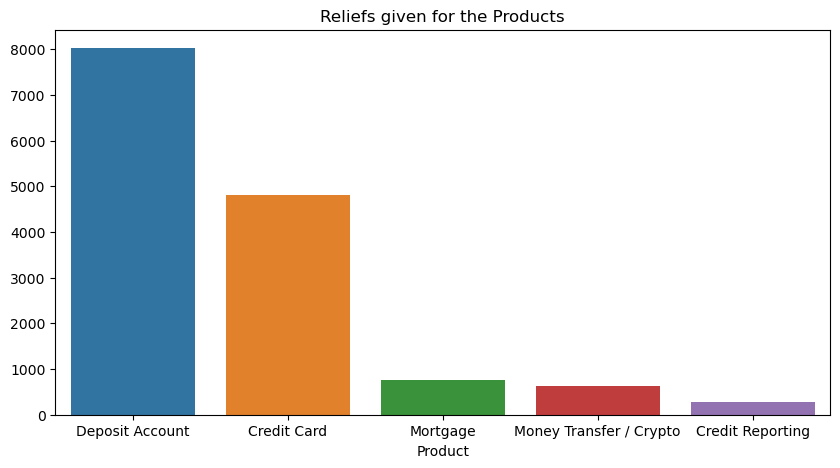

In [62]:
plt.figure(figsize=(10,5))
sns.barplot(y= relief_complaints["No. of Complaints"][:5].values ,x =relief_complaints["Product"][:5])
plt.title("Reliefs given for the Products")
plt.show()

In [63]:
monetary_relief["Issue"].value_counts()[:5]

Issue
Account Management    5206
Purchase Dispute      1811
Account Closure       1029
Incorrect Charge       978
Fees/Interest          722
Name: count, dtype: int64

In [64]:
monetary_relief["Sub-issue"].value_counts()[:5]

Sub-issue
Transaction Issues       5073
Other / Not Specified    1885
Fees & Charges           1846
Account Management       1288
Dispute Resolution       1273
Name: count, dtype: int64

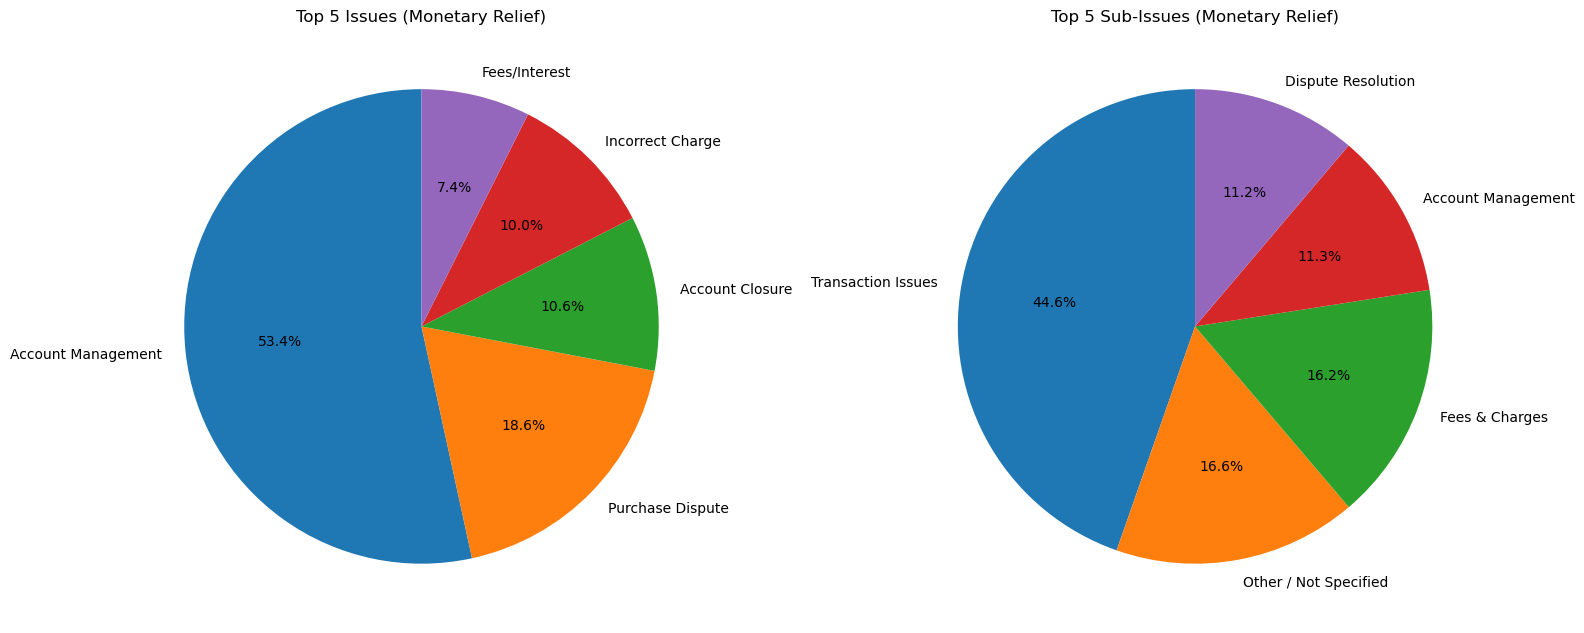

In [65]:
top_issues = monetary_relief["Issue"].value_counts().head(5)
top_subissues = monetary_relief["Sub-issue"].value_counts().head(5)
plt.figure(figsize=(16,10))

# ---- First Pie (Issue) ----
plt.subplot(1, 2, 1)
plt.pie(
    top_issues.values,
    labels=top_issues.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Top 5 Issues (Monetary Relief)")

# ---- Second Pie (Sub-Issue) ----
plt.subplot(1, 2, 2)
plt.pie(
    top_subissues.values,
    labels=top_subissues.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Top 5 Sub-Issues (Monetary Relief)")

plt.tight_layout()
plt.show()

### Insights

Over 60% of monetary relief cases are directly transaction-related.
There may be reporting inconsistency or classification gaps, limiting root cause precision.
This could mean:

1. Poor complaint categorization

2. Weak data governance

3. Inconsistent intake process

Monetary losses are primarily driven by operational failures in transaction processing and account handling within checking accounts.

This suggests:

1. Core banking system stress

2. Reconciliation failures

3. Debit/ATM network issues

4. Dispute resolution inefficiencies

1. Over 50% of monetary compensation cases stem from account management failures, indicating systemic operational weaknesses.

2. Transaction-related errors (deposits, withdrawals, card usage) are the primary drivers of financial remediation.

3. A significant share of unresolved purchase disputes suggests inefficiencies in dispute resolution workflows.

4. The 24% “Not Specified” rate indicates potential data classification or reporting quality issues.

In [68]:
complaints.to_csv("Cleaned complained_ data",index = False)

In [70]:
complaints.isnull().sum()

Complaint ID                        0
Submitted via                       0
Date submitted                      0
Date received                       0
Delay period                        0
Month                               0
State                               0
Product                             0
Sub-product                         0
Issue                               0
Sub-issue                       14077
Company public response             0
Company response to consumer        0
Timely response?                    0
Year                                0
dtype: int64

As per the Graph there is a seasonal increase in complaints between month of june and August and peaks at July